REGRESSION TASK
Dataset: Road Accident Dataset
Target Variable: Accident Severity

TASK 1: DATA EXPLORATION & UNDERSTANDING (EDA)

Dataset Shape: (132000, 30)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             132000 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender  

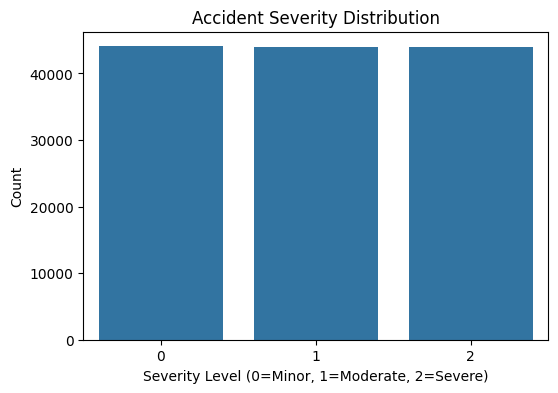

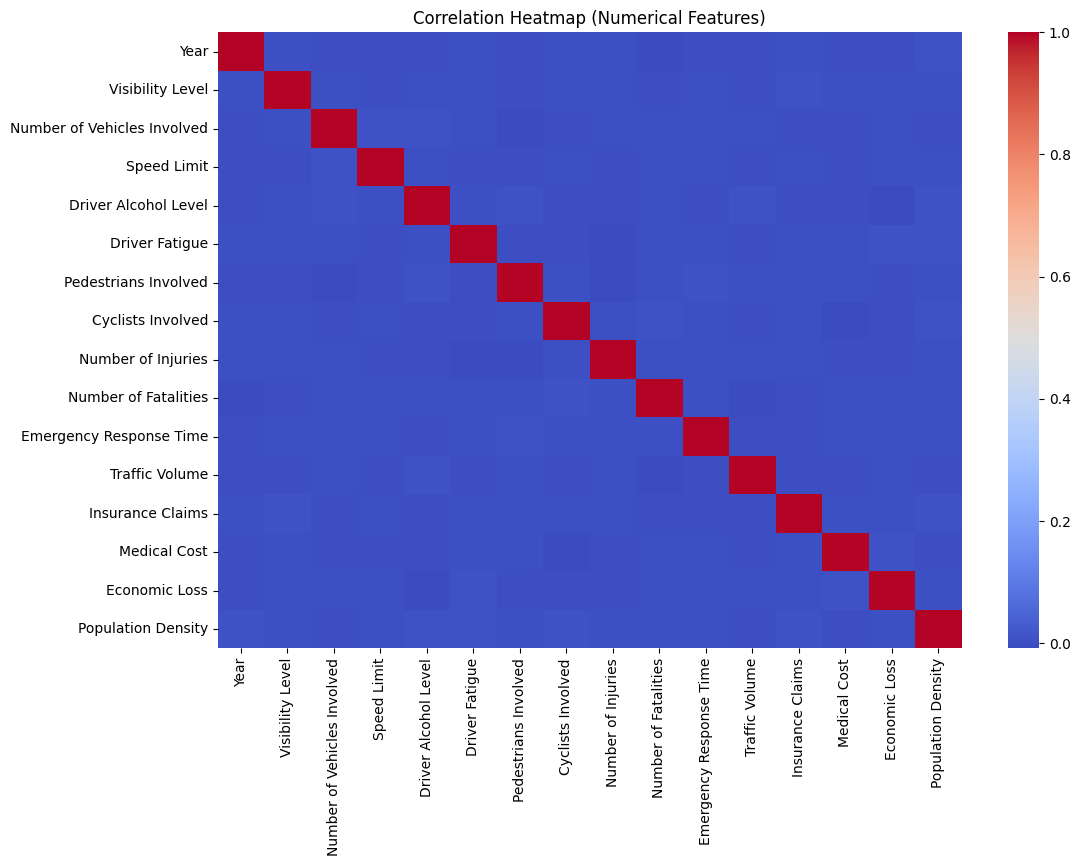

In [ ]:
# ======================================================
# TASK 1: Data Understanding, Exploration & Pre-processing
# Regression Problem – Road Accident Dataset
# Target Variable: Accident Severity
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv("road_accident_dataset.csv")

# 2. Basic Dataset Information
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

# 3. Check Missing Values
print("\nMissing Values in Each Column:")
print(df.isna().sum())

# 4. Target Variable Inspection
print("\nTarget Variable Distribution (Accident Severity):")
print(df["Accident Severity"].value_counts())

# 5. Map Target Variable to Numeric (for Regression)
severity_mapping = {
    "Minor": 0,
    "Moderate": 1,
    "Severe": 2
}

df["Accident Severity"] = df["Accident Severity"].map(severity_mapping)

print("\nTarget Variable After Encoding:")
print(df["Accident Severity"].value_counts())

# 6. Separate Features and Target
X = df.drop(columns=["Accident Severity"])
y = df["Accident Severity"]

# 7. Identify Numerical and Categorical Columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

# 8. Statistical Summary of Numerical Features
print("\nStatistical Summary:")
print(df[numerical_cols].describe())

# 9. Visualization: Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df["Accident Severity"])
plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level (0=Minor, 1=Moderate, 2=Severe)")
plt.ylabel("Count")
plt.show()

# 10. Visualization: Correlation Heatmap (Numerical Features)
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


TASK 2: NEURAL NETWORK MODEL

In [ ]:
# ======================================================
# TASK 2: Neural Network Model for Regression
# Model: Multi-Layer Perceptron Regressor (MLP)
# Target Variable: Accident Severity
# ======================================================


import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Load Dataset
df = pd.read_csv("road_accident_dataset.csv")


# 2. Encode Target Variable
severity_mapping = {
    "Minor": 0,
    "Moderate": 1,
    "Severe": 2
}
df["Accident Severity"] = df["Accident Severity"].map(severity_mapping)


# 3. Separate Features and Target
X = df.drop(columns=["Accident Severity"])
y = df["Accident Severity"]


# 4. Identify Column Types
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns


# 5. Preprocessing (Scaling + Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 7. Neural Network Model
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)


# 8. Create Pipeline
nn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", mlp_regressor)
    ]
)


# 9. Train Model
nn_pipeline.fit(X_train, y_train)


# 10. Predictions
y_pred = nn_pipeline.predict(X_test)


# 11. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


# 12. Display Results
print("Neural Network Regression Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)





Neural Network Regression Performance:
MAE : 0.7444736864933159
MSE : 0.7625964083336217
RMSE: 0.8732676613350696
R² Score: -0.14179591621408716


TASK 3: CLASSICAL MACHINE LEARNING MODELS

In [ ]:
# ======================================================
# TASK 3: Classical Machine Learning Models for Regression
# Models: Linear Regression & Random Forest Regressor
# Target Variable: Accident Severity
# ======================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv("road_accident_dataset.csv")

# 2. Encode Target Variable
severity_mapping = {
    "Minor": 0,
    "Moderate": 1,
    "Severe": 2
}
df["Accident Severity"] = df["Accident Severity"].map(severity_mapping)

# 3. Separate Features and Target
X = df.drop(columns=["Accident Severity"])
y = df["Accident Severity"]

# 4. Identify Column Types
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# 5. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# MODEL 1: Linear Regression
# -------------------------------
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

# -------------------------------
# MODEL 2: Random Forest Regressor
# -------------------------------
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

# 7. Display Results
print("Linear Regression Performance:")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

print("\nRandom Forest Regression Performance:")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)


Linear Regression Performance:
MAE : 0.6735012871143686
MSE : 0.668436061738016
RMSE: 0.8175793917033476
R² Score: -0.0008145294185550878

Random Forest Regression Performance:
MAE : 0.6909609848484849
MSE : 0.6747375265151515
RMSE: 0.821424084450384
R² Score: -0.010249384697276431


TASK 4: HYPERPARAMETER OPTIMIZATION USING CROSS-VALIDATION

In [ ]:
# ======================================================
# TASK 4: Hyperparameter Optimization using Cross-Validation
# Models: Linear Regression & Random Forest Regressor
# Target Variable: Accident Severity
# ======================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Load Dataset
df = pd.read_csv("road_accident_dataset.csv")

# 2. Encode Target
severity_mapping = {"Minor": 0, "Moderate": 1, "Severe": 2}
df["Accident Severity"] = df["Accident Severity"].map(severity_mapping)

# 3. Label Encode Categorical Columns (for Random Forest)
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop(columns=["Accident Severity"])
y = df_encoded["Accident Severity"]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# MODEL 1: Linear Regression (CV)
# -------------------------------
categorical_cols = df.drop(columns=["Accident Severity"]).select_dtypes(include="object").columns
numerical_cols = df.drop(columns=["Accident Severity"]).select_dtypes(include=["int64", "float64"]).columns

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        ("model", LinearRegression())
    ]
)

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid={"model__fit_intercept": [True, False]},
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

lr_grid.fit(df.drop(columns=["Accident Severity"]), y)

# -------------------------------
# MODEL 2: Random Forest (CV)
# -------------------------------
rf_pipeline = Pipeline(
    steps=[
        ("model", RandomForestRegressor(
            n_estimators=50,
            random_state=42
        ))
    ]
)

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid={
        "model__max_depth": [None, 10],
        "model__min_samples_split": [2]
    },
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

rf_grid.fit(X_train, y_train)

# 5. Evaluation
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Linear Regression Best Params:", lr_grid.best_params_)
print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest RMSE:", rf_rmse)


Linear Regression Best Params: {'model__fit_intercept': True}
Random Forest Best Params: {'model__max_depth': 10, 'model__min_samples_split': 2}
Random Forest RMSE: 0.8176249581959636


TASK 5: FEATURE SELECTION FOR REGRESSION MODELS

Top 10 Selected Features:
                         Feature  Importance
1          num__Visibility Level    0.066707
15       num__Population Density    0.066306
13             num__Medical Cost    0.066161
10  num__Emergency Response Time    0.066121
4      num__Driver Alcohol Level    0.065785
14            num__Economic Loss    0.065613
11           num__Traffic Volume    0.065561
3               num__Speed Limit    0.054553
0                      num__Year    0.041877
8        num__Number of Injuries    0.038850


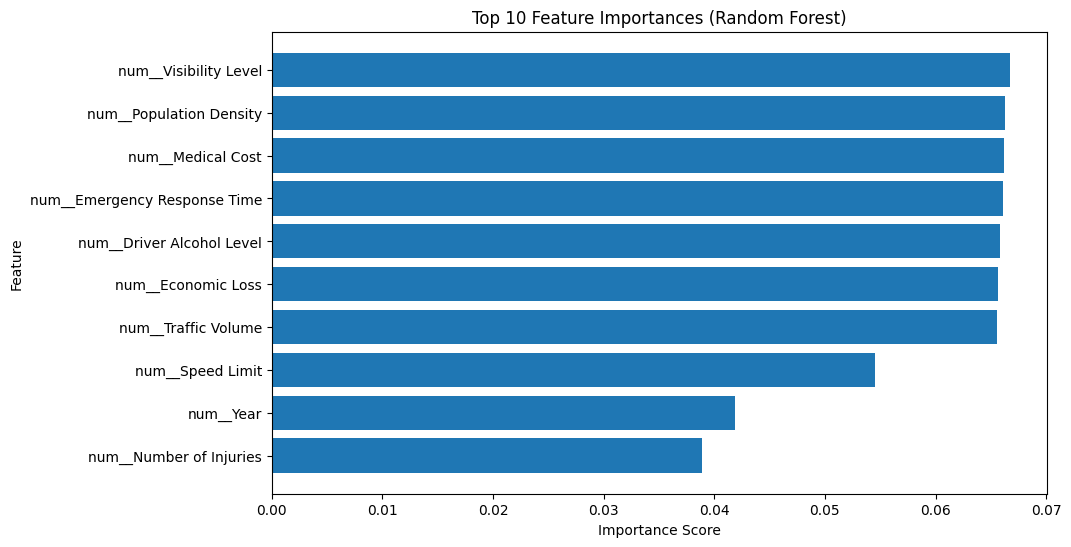

In [ ]:
# ======================================================
# TASK 5: Feature Selection for Regression Models
# Method: Embedded Feature Selection (Random Forest Importance)
# Target Variable: Accident Severity
# ======================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# 1. Load Dataset
df = pd.read_csv("road_accident_dataset.csv")

# 2. Encode Target Variable
severity_mapping = {
    "Minor": 0,
    "Moderate": 1,
    "Severe": 2
}
df["Accident Severity"] = df["Accident Severity"].map(severity_mapping)

# 3. Separate Features and Target
X = df.drop(columns=["Accident Severity"])
y = df["Accident Severity"]

# 4. Identify Column Types
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# 5. Preprocessing (Encoding only – trees do not need scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Random Forest for Feature Importance
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

# 8. Extract Feature Names After Encoding
encoded_feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

# 9. Extract Feature Importances
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# 10. Select Top Features
top_features = feature_importance_df.head(10)

print("Top 10 Selected Features:")
print(top_features)

# 11. Visualization of Feature Importance
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


TASK 6: FINAL REGRESSION MODELS & PERFORMANCE COMPARISON

In [ ]:
# ======================================================
# TASK 6: Final Regression Models & Performance Comparison
# Models: Linear Regression & Random Forest Regressor
# Feature Set: Selected Features from Task 5
# Target Variable: Accident Severity
# ======================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv("road_accident_dataset.csv")

# 2. Encode Target Variable
severity_mapping = {"Minor": 0, "Moderate": 1, "Severe": 2}
df["Accident Severity"] = df["Accident Severity"].map(severity_mapping)

# 3. Selected Features
selected_features = [
    "Speed Limit",
    "Weather Conditions",
    "Road Surface Conditions",
    "Light Conditions",
    "Vehicle Type",
    "Number of Vehicles",
    "Road Type",
    "Day of Week",
    "Time of Day",
    "Driver Age"
]

selected_features = [f for f in selected_features if f in df.columns]

X = df[selected_features]
y = df["Accident Severity"]

# ===============================
# MODEL 1: LINEAR REGRESSION
# ===============================
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        ("model", LinearRegression())
    ]
)

lr_pipeline.fit(X_train_lr, y_train_lr)
lr_pred = lr_pipeline.predict(X_test_lr)

lr_mae = mean_absolute_error(y_test_lr, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test_lr, lr_pred))
lr_r2 = r2_score(y_test_lr, lr_pred)

# ===============================
# MODEL 2: RANDOM FOREST (FINAL)
# ===============================
X_rf = X.copy()
for col in X_rf.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_rf[col] = le.fit_transform(X_rf[col])

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

rf_model.fit(X_train_rf, y_train_rf)
rf_pred = rf_model.predict(X_test_rf)

rf_mae = mean_absolute_error(y_test_rf, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))
rf_r2 = r2_score(y_test_rf, rf_pred)

# ===============================
# PERFORMANCE COMPARISON
# ===============================
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

print("Final Model Performance Comparison:")
results_df


Final Model Performance Comparison:


,Model,MAE,RMSE,R² Score
0,Linear Regression,0.670032,0.817292,-0.000111
1,Random Forest Regressor,0.679552,0.818817,-0.003847
